# Muography analysis visualisation

This notebook displays the figures and numerical summary created by `analysis/run_analysis.py`. Run that script first if the files are absent or need refreshing.

In [7]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'analysis').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent

FIG_DIR = PROJECT_ROOT / 'analysis' / 'figures'
RESULTS_FILE = PROJECT_ROOT / 'results' / 'analysis_results.json'

assert FIG_DIR.is_dir(), f'Missing figure directory: {FIG_DIR}'
assert RESULTS_FILE.is_file(), f'Missing results file: {RESULTS_FILE}'
print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/chuene/Documents/Documents-Chuene/Muography


In [8]:
with RESULTS_FILE.open() as f:
    results = json.load(f)

run = results['run']
print(f"Input: {run['file']}")
print(f"Events: {run['n_events']:,}")
print(f"Open-sky rate: {run['rate_hz']:.2f} Hz ({run['rate_per_day']:.0f} per day)")
print(f"Clean-event fraction: {results['clean_fraction']['fraction']:.1%}")
print(f"Classifier AUC: {results['classifier']['auc']:.3f}")
print(f"Estimated overburden: {results['overburden']['depth_mwe_exact_model']:.0f} m.w.e.")

Input: PAUL_UWC_CALIB2_12APR2024-0.dat
Events: 8,420
Open-sky rate: 14.03 Hz (1212480 per day)
Clean-event fraction: 91.6%
Classifier AUC: 1.000
Estimated overburden: 651 m.w.e.


## Generated figures


Event quality


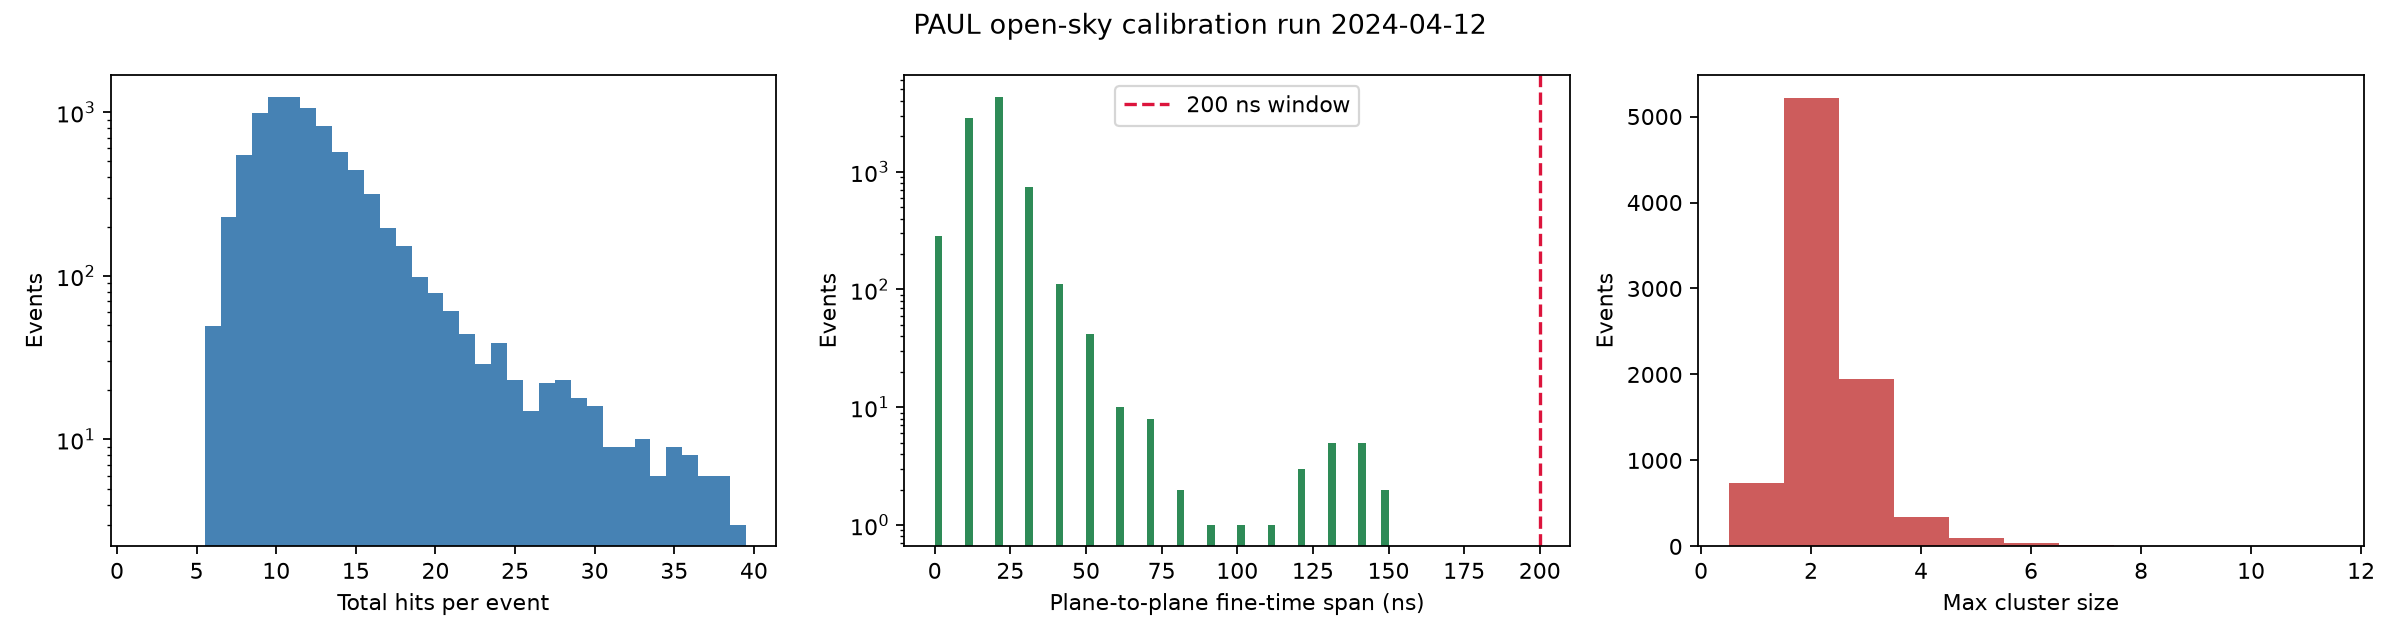


Angular distributions


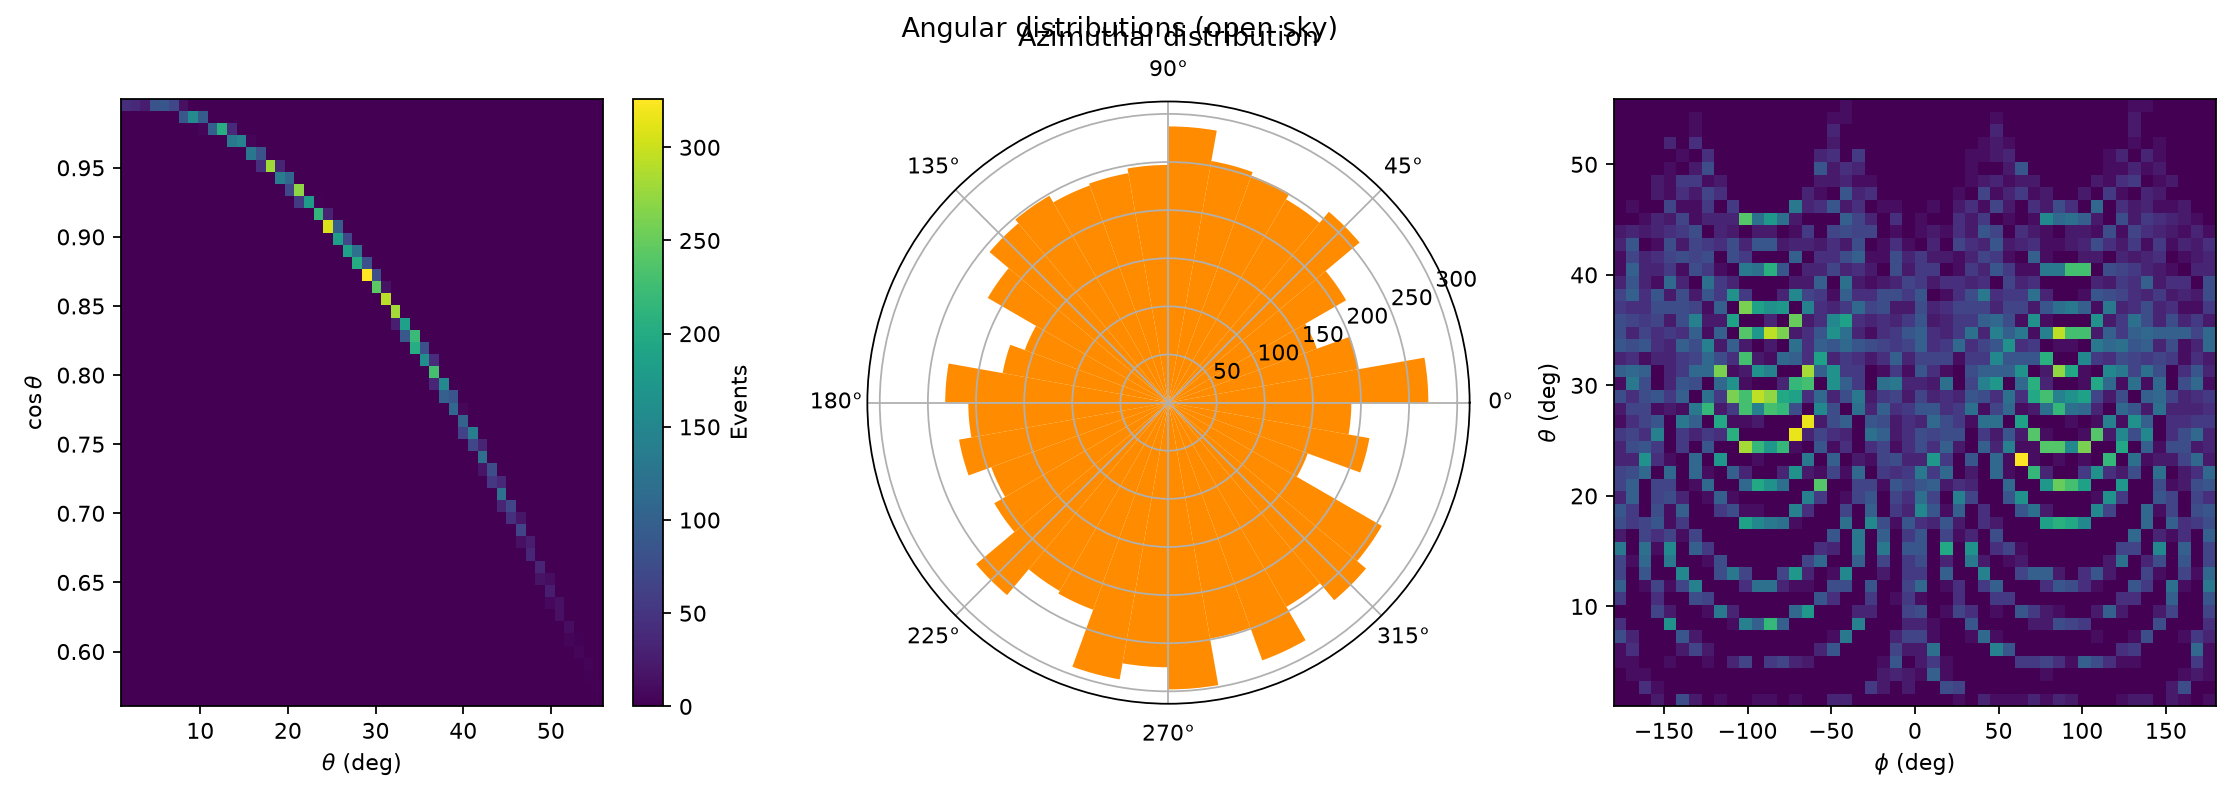


Strip occupancy and clusters


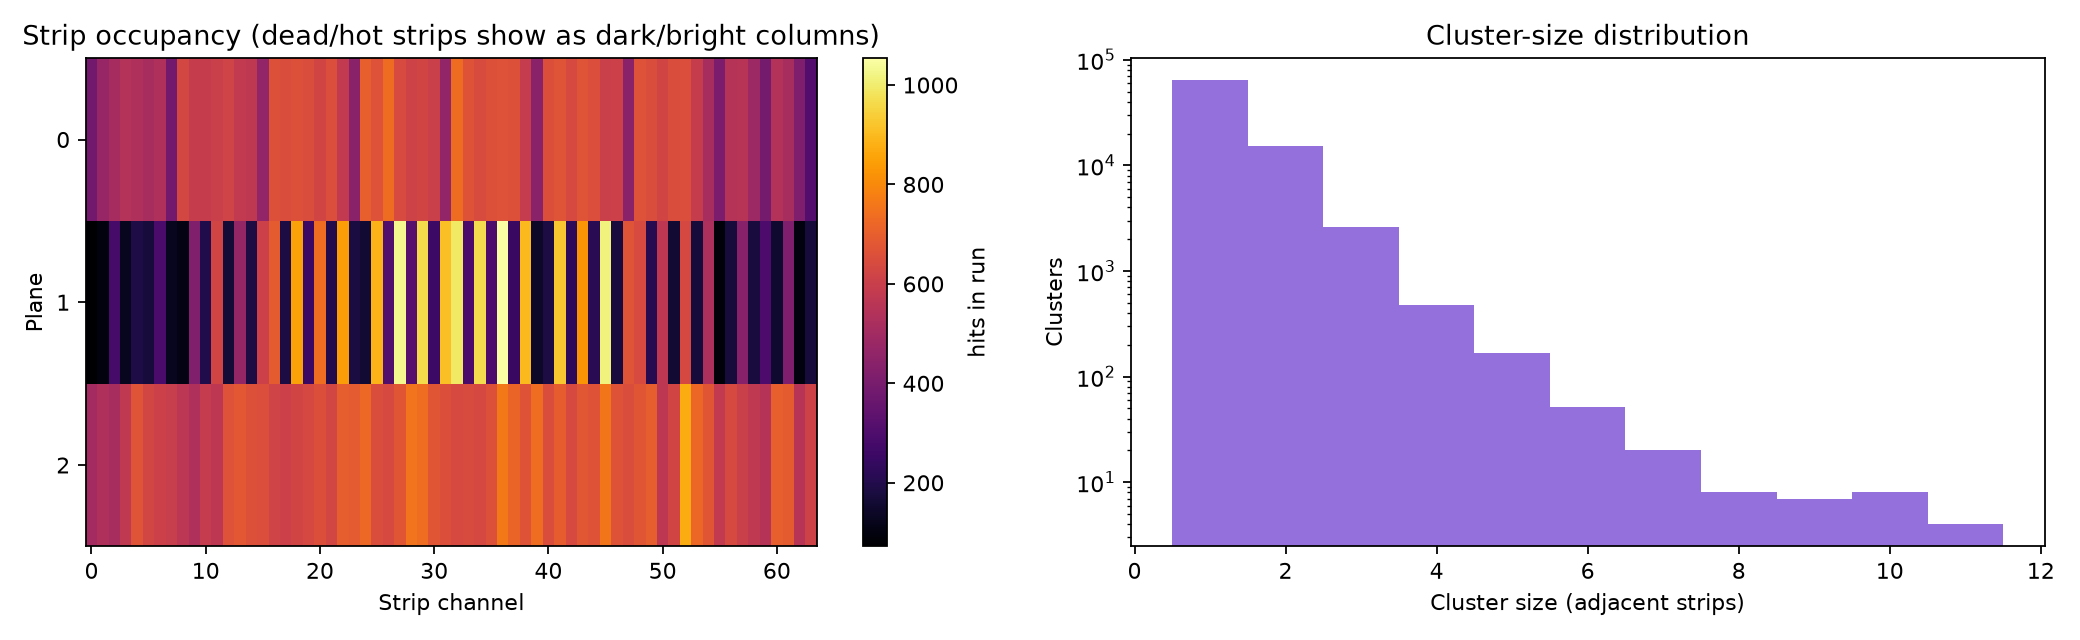


Anomaly scores


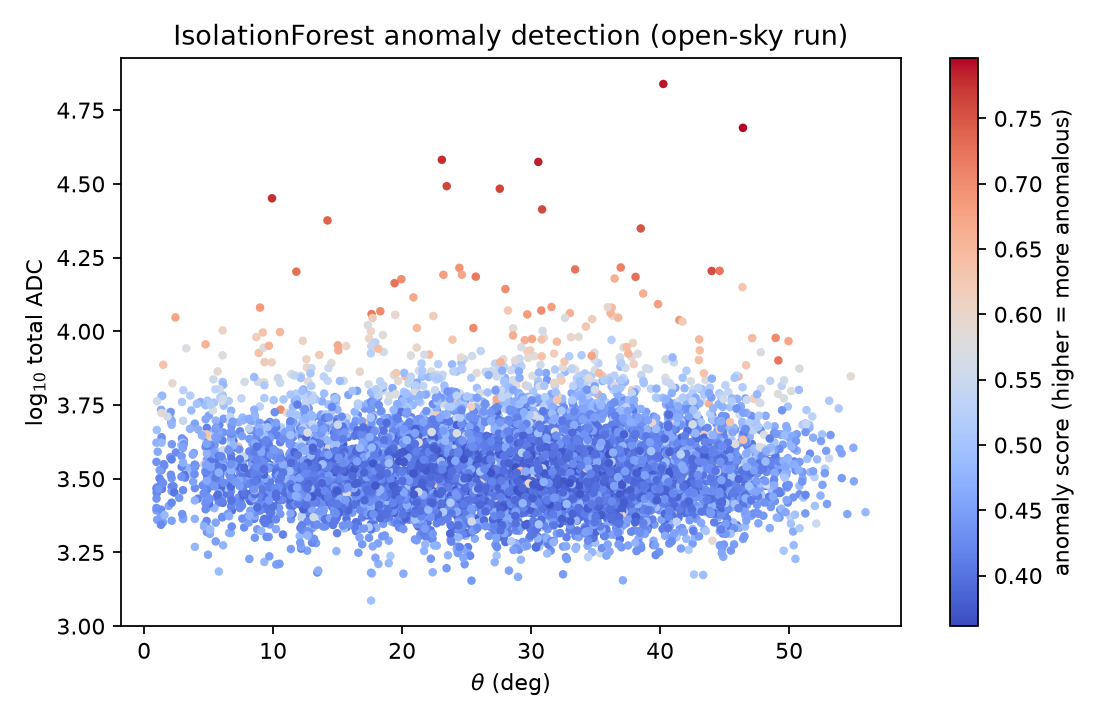


Classifier feature importance


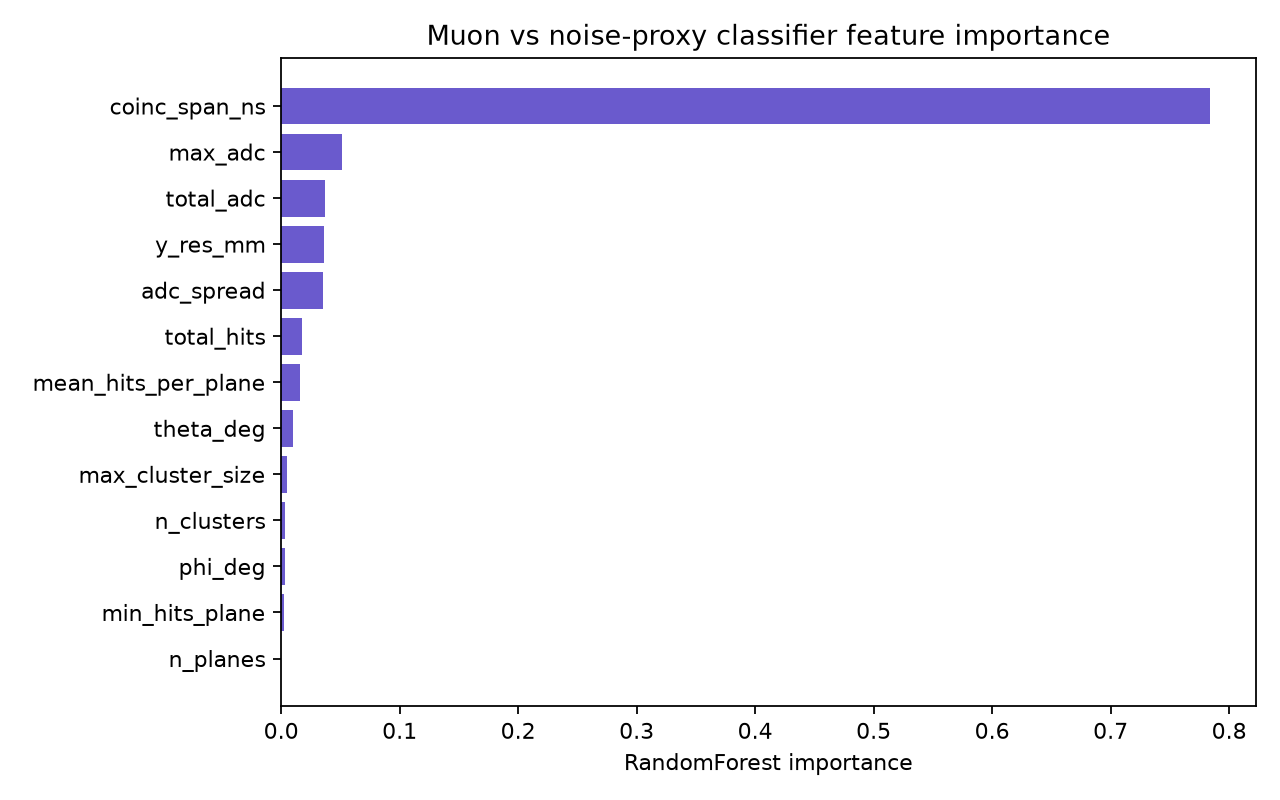


Transmission and overburden


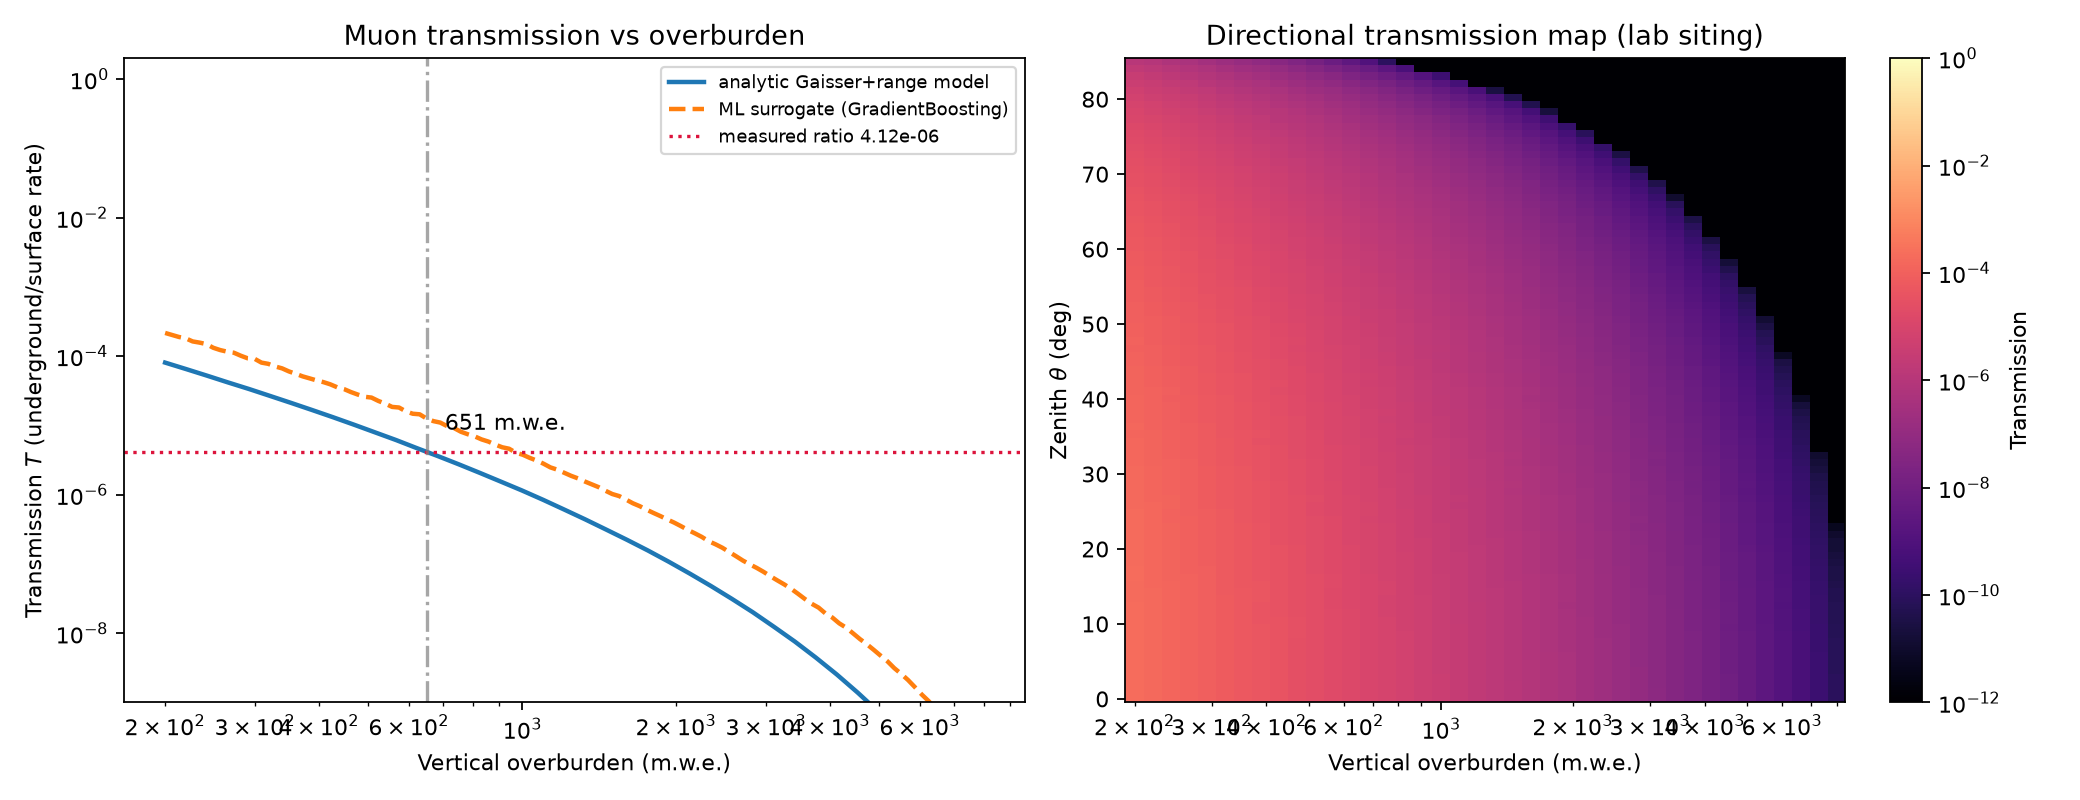


Time stability


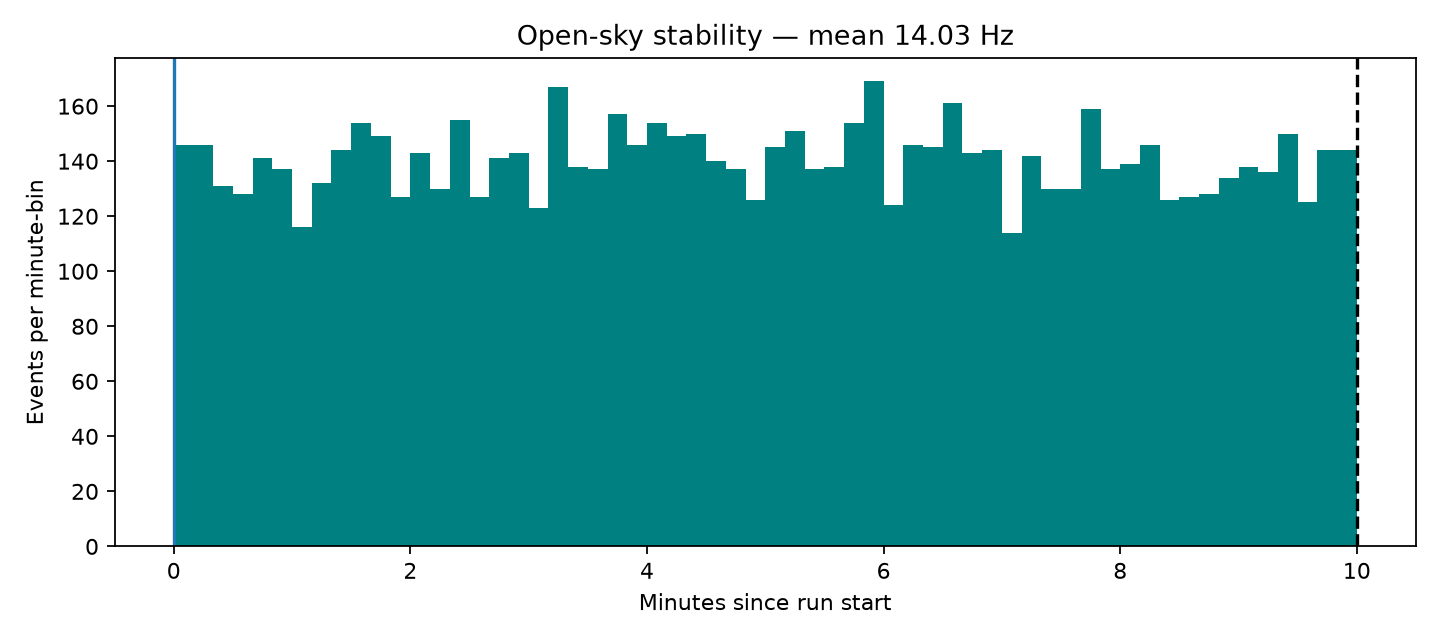

In [9]:
figures = [
    ('Event quality', 'event_quality.png'),
    ('Angular distributions', 'angular_open_sky.png'),
    ('Strip occupancy and clusters', 'occupancy_clusters.png'),
    ('Anomaly scores', 'anomaly_scores.png'),
    ('Classifier feature importance', 'rf_feature_importance.png'),
    ('Transmission and overburden', 'transmission_overburden.png'),
    ('Time stability', 'time_stability.png'),
]

for title, filename in figures:
    image_path = FIG_DIR / filename
    print(f'\n{title}')
    display(Image(filename=str(image_path)))